# Pinchot Python wrapper walkthrough

An end-to-end tour of the `joescan_pinchot` package against a live JS-50 scan
head: discovery, configuration, diagnostic image and profile captures, and
real-time scanning — with plots along the way.

Requirements:

- a built native `pinchot` library (see the [README](../README.md) for where
  the wrapper looks for it),
- a JS-50 scan head reachable on the network,
- `matplotlib` and `numpy` (`pip install matplotlib numpy`).

Set `SERIAL` below to your scan head's serial number, then run the cells in
order.

In [1]:
import sys, pathlib

# Allow running straight from a repo checkout without `pip install -e`.
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

import joescan_pinchot as js

SERIAL = 23185

print("Pinchot API:", js.get_api_version())

Pinchot API: 16.3.2+00c0534


## Discovery

`ScanSystem` is the root object; it is also a context manager, but here we
keep it open across cells and free it explicitly at the end. `discover()`
broadcasts on the local network and returns the number of heads that
responded.

In [2]:
system = js.ScanSystem(js.Units.INCHES)

n = system.discover()
print(f"{n} scan head(s) on the network:\n")
for d in system.get_discovered():
    fw = ".".join(str(v) for v in d.firmware_version)
    print(f"  serial {d.serial_number}  {d.type_str:10s}  fw {fw}"
          f"  ip {d.ip_address}  link {d.link_speed_mbps} Mbps")

2 scan head(s) on the network:



  serial 22017  JS-50 WX    fw 16.2.3  ip 192.168.1.13  link 1000 Mbps
  serial 23185  JS-50 WSC   fw 16.3.1  ip 192.168.1.31  link 1000 Mbps


## Create and configure a scan head

Configuration is a plain `jsScanHeadConfiguration` struct. The scan window
bounds the region the head will measure, and the alignment transforms camera
coordinates into your machine's coordinate system.

In [3]:
head = system.create_scan_head(serial=SERIAL, id=0)

caps = head.get_capabilities()
fw = ".".join(str(v) for v in head.get_firmware_version())
print(f"type {head.type.name}, {caps.num_cameras} camera(s), "
      f"{caps.num_lasers} laser(s), firmware {fw}")

cfg = head.get_configuration_default()
cfg.laser_on_time_min_us = 100
cfg.laser_on_time_def_us = 100
cfg.laser_on_time_max_us = 1000
head.set_configuration(cfg)

head.set_window_rectangular(30.0, -30.0, -30.0, 30.0)
head.set_alignment(0.0, 0.0, 0.0)

type JS50WSC, 1 camera(s), 1 laser(s), firmware 16.3.1


## Phase table and connect

The phase table defines the scan order. This head is camera-driven, so a
single phase with camera A is enough. `connect()` must come after the head is
configured.

In [4]:
system.phase_create()
system.phase_insert_camera(head, js.Camera.A)

system.connect(timeout_s=5)

status = head.get_status()
print(f"connected; head time {status.global_time_ns / 1e9:.3f} s, "
      f"{status.num_profiles_sent} profiles sent so far")

connected; head time 89048.047 s, 201 profiles sent so far


## Diagnostic image

`get_diagnostic_image_camera()` grabs one full sensor frame — useful for
checking what the camera actually sees. The returned `CameraImage` exposes
the raw 8-bit pixels and can be written to disk as a standard BMP with
`.save(path)`.

The raw capture is nearly black (a short exposure admits little ambient
light), so alongside it we show a gamma-boosted view where the laser line is
obvious.

CameraImage(scan_head_id=0, camera=A, laser=L1, width=1456, height=1088)


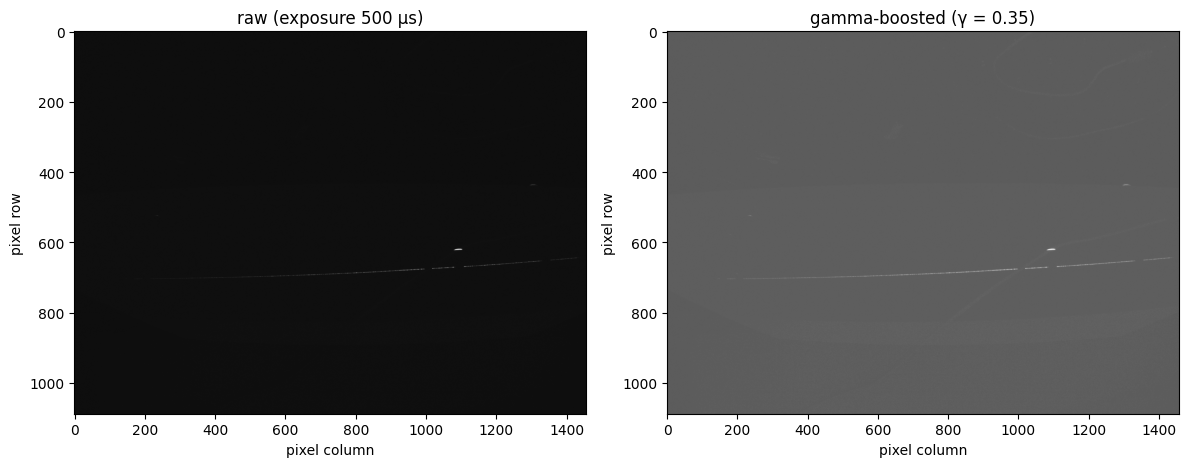

In [5]:
img = head.get_diagnostic_image_camera(
    js.Camera.A, laser_on_time_us=100, camera_exposure_time_us=500)
print(img)

pixels = np.frombuffer(img.pixels, dtype=np.uint8).reshape(img.height, img.width)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(pixels, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"raw (exposure {img.camera_exposure_time_us} \u00b5s)")
axes[1].imshow((pixels / 255.0) ** 0.35, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("gamma-boosted (\u03b3 = 0.35)")
for ax in axes:
    ax.set_xlabel("pixel column")
    ax.set_ylabel("pixel row")
fig.tight_layout()
plt.show()

# img.save("diagnostic.bmp")  # standard BMP, viewable anywhere

## Diagnostic profile

`get_diagnostic_profile_camera()` runs a single profile measurement outside
of normal scanning. It returns a raw `jsRawProfile`; invalid columns are
marked with `JS_PROFILE_DATA_INVALID_XY` and filtered out here. Raw x/y are
in 1/1000ths of the scan-system units.

1019 valid points of 1456 columns


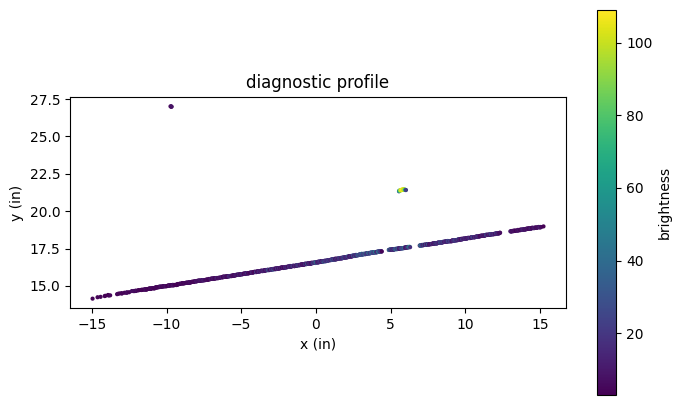

In [6]:
raw = head.get_diagnostic_profile_camera(
    js.Camera.A, laser_on_time_us=100, camera_exposure_time_us=500)

pts = np.array([(d.x / 1000.0, d.y / 1000.0, d.brightness)
                for d in raw.data[:raw.data_len]
                if d.x != js.JS_PROFILE_DATA_INVALID_XY])
print(f"{raw.data_valid_xy} valid points of {raw.data_len} columns")

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 2], cmap="viridis", s=4)
fig.colorbar(sc, ax=ax, label="brightness")
ax.set_xlabel("x (in)")
ax.set_ylabel("y (in)")
ax.set_title("diagnostic profile")
ax.set_aspect("equal")
plt.show()

## Scanning

Start scanning, read a batch of profiles, and stop. `get_profiles()` returns
`Profile` objects whose `.data` holds only the valid points, already scaled
into scan-system units.

In [7]:
period_us = max(system.get_min_scan_period(), 1000)
print(f"scan period {period_us} \u00b5s "
      f"({1e6 / period_us:.0f} profiles/s)")

system.start_scanning(period_us, js.DataFormat.XY_BRIGHTNESS_FULL)

head.wait_until_profiles_available(200, timeout_us=5_000_000)
profiles = head.get_profiles(200)

system.stop_scanning()
print(f"read {len(profiles)} profiles; "
      f"first has {len(profiles[0].data)} valid points")

scan period 1670 µs (599 profiles/s)


read 200 profiles; first has 1020 valid points


### A single profile

One scan line, colored by measured brightness.

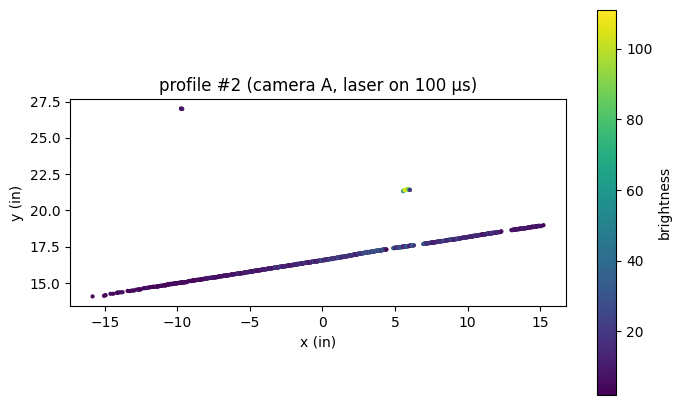

In [8]:
p = profiles[0]
xy = np.array([(pt.x, pt.y, pt.brightness) for pt in p.data])

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(xy[:, 0], xy[:, 1], c=xy[:, 2], cmap="viridis", s=4)
fig.colorbar(sc, ax=ax, label="brightness")
ax.set_xlabel("x (in)")
ax.set_ylabel("y (in)")
ax.set_title(f"profile #{p.sequence_number} "
             f"(camera {p.camera.name}, laser on {p.laser_on_time_us} \u00b5s)")
ax.set_aspect("equal")
plt.show()

### Profiles over time

All profiles overlaid, colored by capture order. With a static scene the
lines coincide; anything moving through the laser shows up as drift.

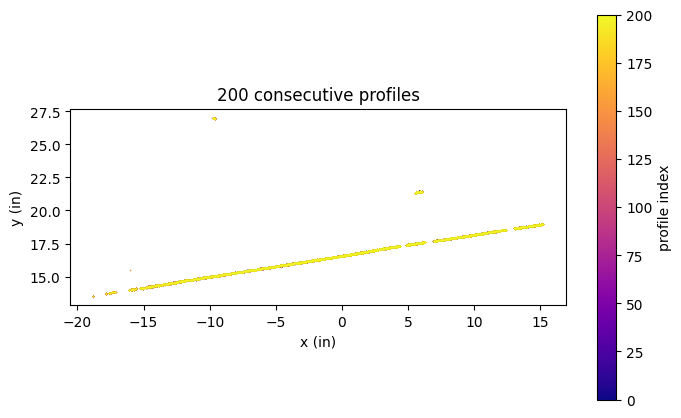

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.get_cmap("plasma")
for i, p in enumerate(profiles):
    xy = np.array([(pt.x, pt.y) for pt in p.data])
    if len(xy):
        ax.scatter(xy[:, 0], xy[:, 1],
                   color=cmap(i / max(len(profiles) - 1, 1)),
                   s=1, alpha=0.3, linewidths=0)
sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=plt.Normalize(0, len(profiles)))
fig.colorbar(sm, ax=ax, label="profile index")
ax.set_xlabel("x (in)")
ax.set_ylabel("y (in)")
ax.set_title(f"{len(profiles)} consecutive profiles")
ax.set_aspect("equal")
plt.show()

### Waterfall

Height (`y`) as a function of `x` and time — profiles resampled onto a
common x grid and stacked into an image.

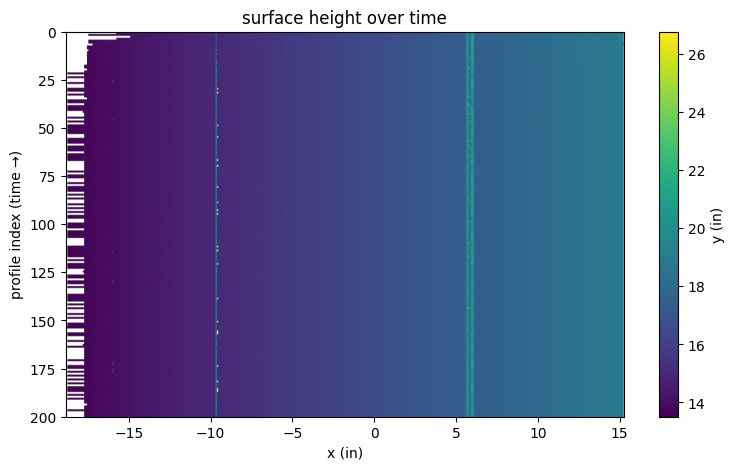

In [10]:
x_grid = np.linspace(
    min(pt.x for p in profiles for pt in p.data),
    max(pt.x for p in profiles for pt in p.data), 400)

rows = []
for p in profiles:
    xy = np.array([(pt.x, pt.y) for pt in p.data])
    order = np.argsort(xy[:, 0])
    rows.append(np.interp(x_grid, xy[order, 0], xy[order, 1],
                          left=np.nan, right=np.nan))
waterfall = np.vstack(rows)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(waterfall, aspect="auto", cmap="viridis",
               extent=[x_grid[0], x_grid[-1], len(profiles), 0])
fig.colorbar(im, ax=ax, label="y (in)")
ax.set_xlabel("x (in)")
ax.set_ylabel("profile index (time \u2192)")
ax.set_title("surface height over time")
plt.show()

## Clean up

Disconnect and free the native scan system.

In [11]:
system.disconnect()
system.free()
print("done")

done
